In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint

In [2]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("HUGGINGFACEHUB_API_TOKEN")

In [3]:
from typing import TypedDict

In [4]:
llm = HuggingFaceEndpoint(
    repo_id='mistralai/Mistral-7B-Instruct-v0.2',
    temperature=0.1,
    max_new_tokens=2048,
    huggingfacehub_api_token=secret_value_0
)
model = ChatHuggingFace(llm=llm)

In [5]:
class LlmState(TypedDict):
    question: str
    answer: str

In [6]:
def qa(state:LlmState)->LlmState:
    q=state['question']
    prom=f'Give answer to {q}'
    state['answer']=model.invoke(prom).content
    return state

In [7]:
graph = StateGraph(LlmState)

In [8]:
graph.add_node('qallm',qa)

In [9]:
graph.add_edge(START,'qallm')
graph.add_edge('qallm',END)

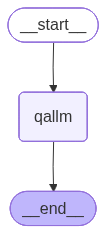

In [10]:
graph.compile()

In [11]:
a=graph.compile()

In [12]:
out=a.invoke({'question':'What are the different components of car?'})

In [13]:
print(out['answer'])

A car is composed of numerous components that work together to ensure its proper functioning, safety, and performance. Here’s a breakdown of the major **components and systems** in a typical automobile:

---

### **1. Engine & Powertrain**
- **Engine**: The heart of the car, responsible for converting fuel into mechanical energy.
  - *Internal Combustion Engine (ICE)*: Gasoline (petrol) or diesel engine.
  - *Electric Motor*: In hybrid or fully electric vehicles (EVs).
  - *Components*: Cylinder block, pistons, crankshaft, camshaft, valves, spark plugs (gasoline), fuel injectors, intake/exhaust manifolds, cylinder head, etc.
- **Fuel System**:
  - Fuel tank, fuel pump, fuel filter, fuel injectors (or carburetor in older cars), and fuel lines.
- **Lubrication System**:
  - Oil pump, oil filter, oil pan, and engine oil.
- **Cooling System**:
  - Radiator, water pump, thermostat, cooling fan, and antifreeze.
- **Exhaust System**:
  - Exhaust manifold, catalytic converter, muffler, and tai